In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from src.preprocessing.preprocessing import (
    load_data,
    clean_data,
    prepare_features,
    build_preprocessing_pipeline
)

In [4]:
df = clean_data(load_data("../data/raw/amazon_sales_dataset.csv"))
X, y = prepare_features(df, target="discounted_price")
X.shape, y.shape

((50000, 10), (50000,))

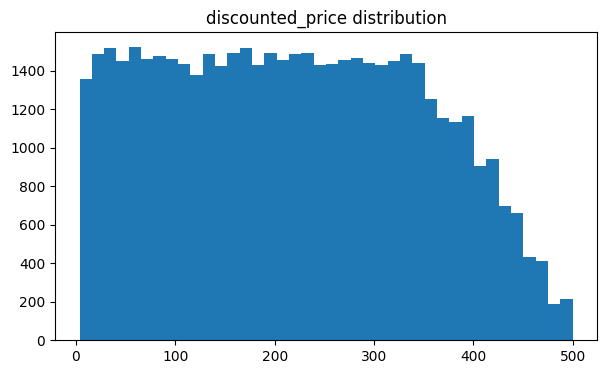

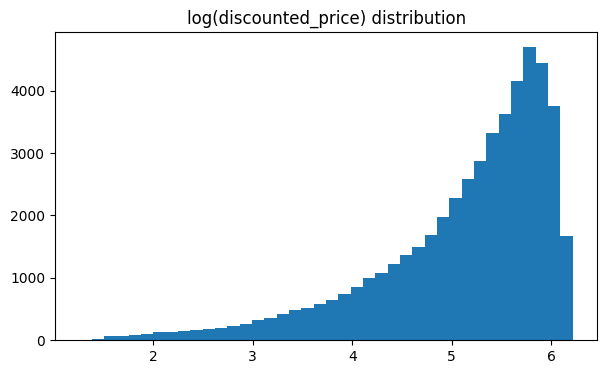

In [5]:
plt.figure(figsize=(7,4))
plt.hist(y, bins=40)
plt.title("discounted_price distribution")
plt.show()

plt.figure(figsize=(7,4))
plt.hist(np.log(y.clip(lower=1e-9)), bins=40)
plt.title("log(discounted_price) distribution")
plt.show()

In [6]:
pre = build_preprocessing_pipeline(X)

model = Pipeline([
    ("preprocess", pre),
    ("model", BayesianRidge())
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error", "r2": "r2"}

cv_res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True)
(-cv_res["test_rmse"]).mean(), (-cv_res["test_rmse"]).std()

(np.float64(14.02039606506041), np.float64(0.10027094784659668))

In [7]:
model.fit(X_train, y_train)

pred_tr = model.predict(X_train)
pred_te = model.predict(X_test)

rmse_tr = np.sqrt(mean_squared_error(y_train, pred_tr))
rmse_te = np.sqrt(mean_squared_error(y_test, pred_te))

gap = (rmse_te - rmse_tr) / rmse_tr

print("RMSE train:", rmse_tr)
print("RMSE test :", rmse_te)
print("Gap ratio :", gap)
print("MAE test  :", mean_absolute_error(y_test, pred_te))
print("R2 test   :", r2_score(y_test, pred_te))

RMSE train: 14.01163809981848
RMSE test : 14.311832914771482
Gap ratio : 0.021424676602009245
MAE test  : 10.519086185522891
R2 test   : 0.9873348722164188


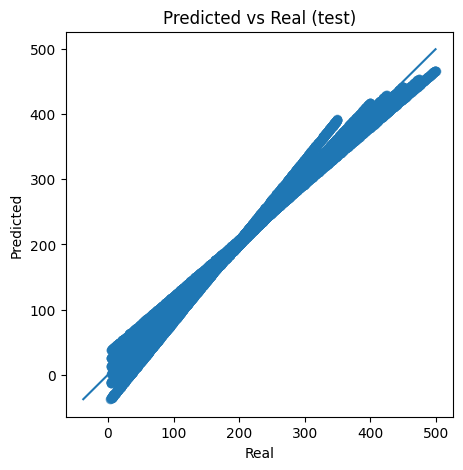

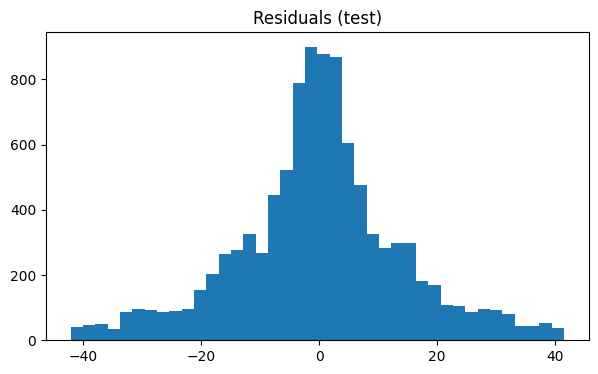

In [8]:
plt.figure(figsize=(5,5))
plt.scatter(y_test, pred_te, alpha=0.6)
mn = min(y_test.min(), pred_te.min())
mx = max(y_test.max(), pred_te.max())
plt.plot([mn, mx], [mn, mx])
plt.title("Predicted vs Real (test)")
plt.xlabel("Real")
plt.ylabel("Predicted")
plt.show()

res = y_test - pred_te
plt.figure(figsize=(7,4))
plt.hist(res, bins=40)
plt.title("Residuals (test)")
plt.show()

In [ ]:
import json

with open("../reports/metrics/metrics_baseline.json", "r", encoding="utf-8") as f:
    report = json.load(f)

report

{'target': 'discounted_price',
 'use_log_target': False,
 'cv': {'train_rmse_mean': 14.010573102151204,
  'train_rmse_std': 0.024835309619897283,
  'test_rmse_mean': 14.02039606506041,
  'test_rmse_std': 0.10027094784659668,
  'train_mae_mean': 10.240164418465437,
  'test_mae_mean': 10.247612991885301,
  'train_r2_mean': 0.9878964778871909,
  'test_r2_mean': 0.9878752293639362},
 'holdout': {'train': {'rmse': 14.01163809981848,
   'mae': 10.240785456050151,
   'r2': 0.9878949182081096},
  'test': {'rmse': 14.311832914771482,
   'mae': 10.519086185522891,
   'r2': 0.9873348722164188},
  'rmse_gap_ratio': 0.021424676602009245},
 'artifact': 'models\\bayesridge.joblib'}